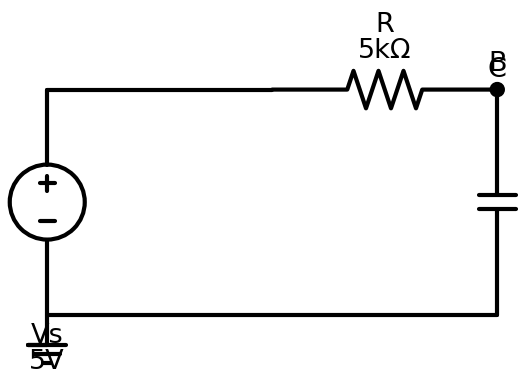

In [7]:
import schemdraw
import schemdraw.elements as elm
from IPython.display import Image, display

with schemdraw.Drawing(show=False) as d:
    d.config(fontsize=13)
    V1 = d.add(elm.SourceV().up().label('Vs\n5V', loc='left'))
    d.add(elm.Line().right())
    d.add(elm.Resistor().right().label('R\n5kΩ', loc='top'))
    d.add(elm.Dot().label('B', loc='top'))
    d.add(elm.Capacitor().down().label('C', loc='right'))
    d.add(elm.Line().left().tox(V1.start))
    d.add(elm.Ground())
    d.save('time_constant_1_fig.png', dpi=150)

display(Image('time_constant_1_fig.png', width=210))
    

In [8]:
%pycat time_constant_1_orig.in

Time Constant 1
Vs in 0 DC 5
R1 in vb 5000
C1 vb 0 $C IC=1
.TRAN 0.5u 2500u UIC
.END


In [9]:
import ngspice_calc as calc

s_C = '100n'
l = [('$C', s_C)]
calc.replace_strings_1('time_constant_1_orig.in', 'time_constant_1.in', l)
print('file ready')

file ready


In [10]:
calc.run_ngspice('time_constant_1.in')


Note: No compatibility mode selected!


Circuit: time constant 1

binary raw file "time_constant_1.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

Using SPARSE 1.3 as Direct Linear Solver
No. of Data Columns : 4  
Operating point simulation skipped by 'uic',
  now using transient initial conditions.

No. of Data Rows : 5011

Total analysis time (seconds) = 0.0117939

Total elapsed time (seconds) = 0.013 

Total DRAM available = 15614.746 MB.
DRAM currently available = 1763.430 MB.
Maximum ngspice program size =   21.406 MB.
Current ngspice program size =   12.680 MB.

Shared ngspice pages =   10.902 MB.
Text (code) pages =    7.105 MB.
Stack = 0 bytes.
Library pages =    1.879 MB.




'time_constant_1.raw'

In [11]:
import numpy as np

VC1 = 4.5

s = calc.slv('time_constant_1.in')
t = s.get_array('time')
VB = s.get_array('v(vb)')
IR = s.get_array('i(vs)')

crossings = calc.cross_over_points(t, VB, VC1)
print(f'time points at which VC crosses {VC1:.2f}')
for t1 in crossings:
    print(f'   {t1*1e6:.2f} micro-sec')

time points at which VC crosses 4.50
   1039.22 micro-sec


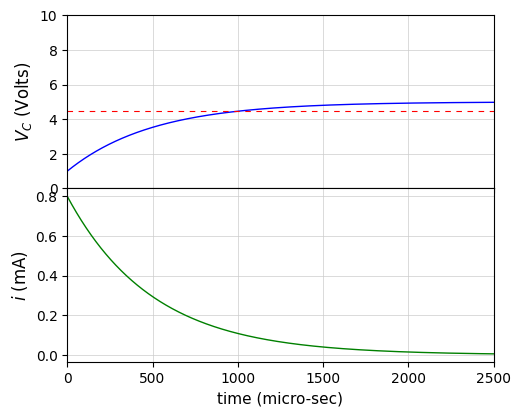

In [12]:
import matplotlib.pyplot as plt

color1 = 'blue'
color2 = 'green'
color3 = 'red'

fig, ax = plt.subplots(2, sharex=False, figsize=(5.5, 4.5))
plt.subplots_adjust(wspace=0, hspace=0.0)

for i in range(2):
    ax[i].set_xlim(left=0.0, right=t[-1] * 1e6)
    ax[i].grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)

ax[0].set_ylim(bottom=0.0, top=10.0)
ax[0].set_ylabel(r'$V_C$ (Volts)', fontsize=12)
ax[1].set_ylabel(r'$i$ (mA)', fontsize=12)
ax[0].tick_params(labelbottom=False)

ax[0].plot(t * 1e6, VB,        color=color1, linewidth=1.0, label=r'$V_C$')
ax[1].plot(t * 1e6, -IR * 1e3, color=color2, linewidth=1.0, label=r'$i$')

ax[0].axhline(y=VC1, color=color3, linestyle='--', linewidth=0.8, dashes=(5, 5))

ax[1].set_xlabel('time (micro-sec)', fontsize=11)

plt.show()